In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
wine_red = pd.read_csv('./data/winequality-red.csv', sep=';')
wine_white = pd.read_csv('./data/winequality-white.csv', sep=';')

In [10]:
wine_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
wine_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [12]:
wine_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [13]:
wine_white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [14]:
wine_white['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

In [107]:
PURPLE  = '#7f77dd'
TEAL    = '#1d9e75'
CORAL   = '#d85a30'
BLUE    = '#378add'
PINK    = '#d4537e'
MUTED   = '#888780'

plt.rcParams['figure.facecolor'] = 'white'

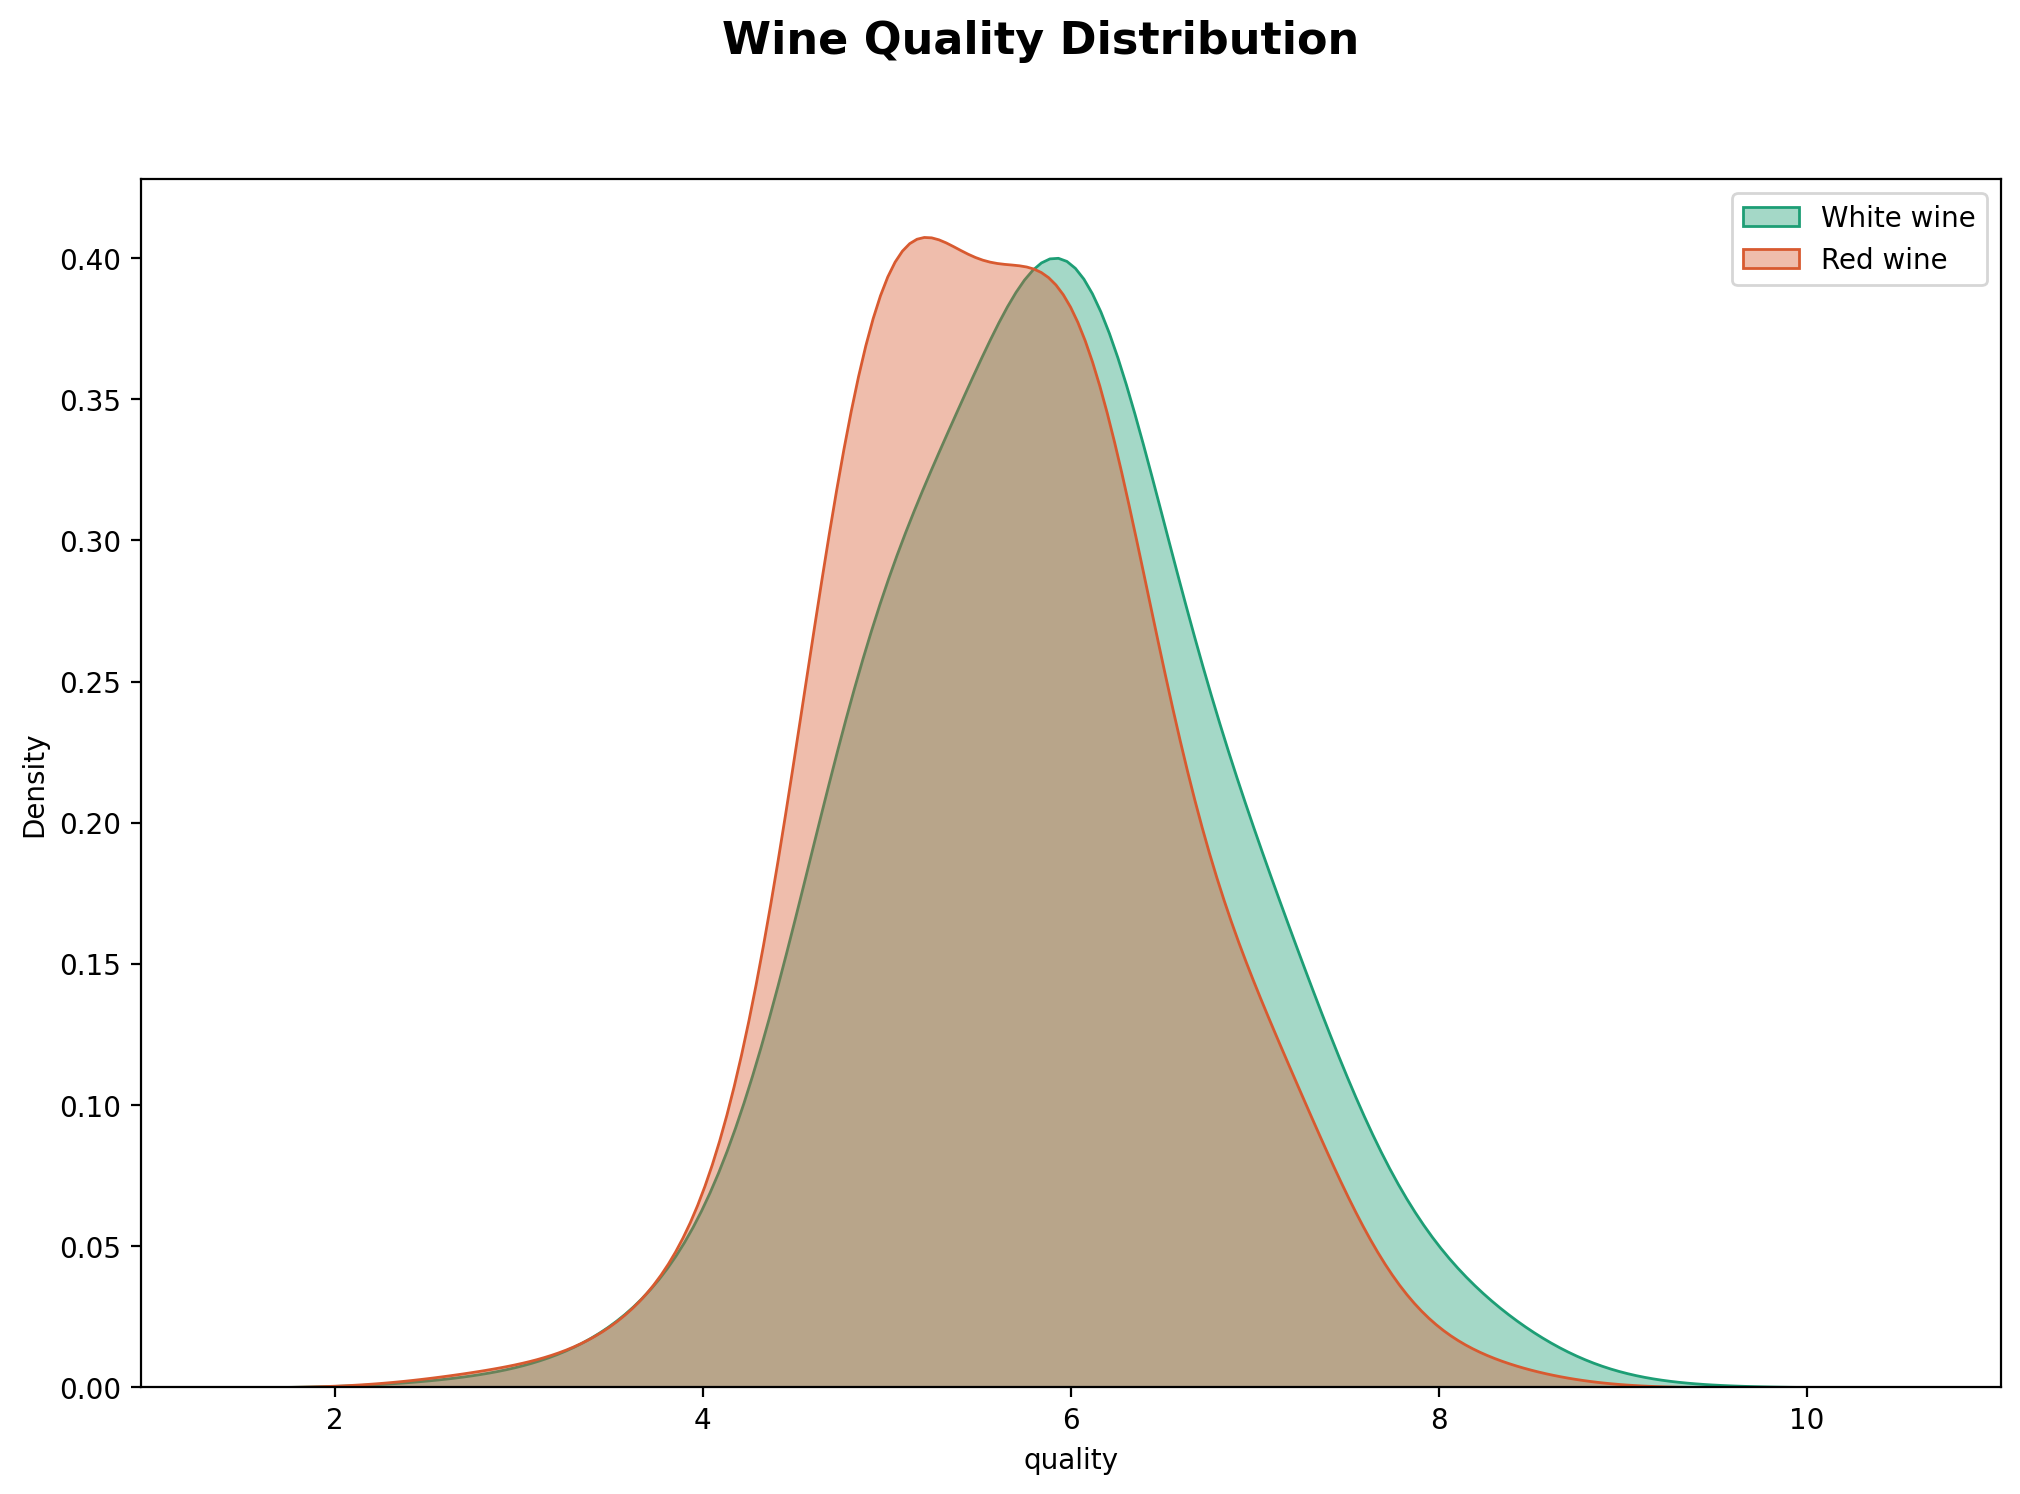

In [108]:
fig, axes = plt.subplots(figsize=(12, 8), dpi=200)

sns.kdeplot(wine_white['quality'], label='White wine', fill=True, alpha=0.4, bw_method=0.6, color=TEAL)
sns.kdeplot(wine_red['quality'], label='Red wine', fill=True, alpha=0.4, bw_method=0.6, color=CORAL)

plt.legend()
plt.suptitle('Wine Quality Distribution', fontsize=16, fontweight='bold')
#plt.savefig('images/wine-quality-distribution')

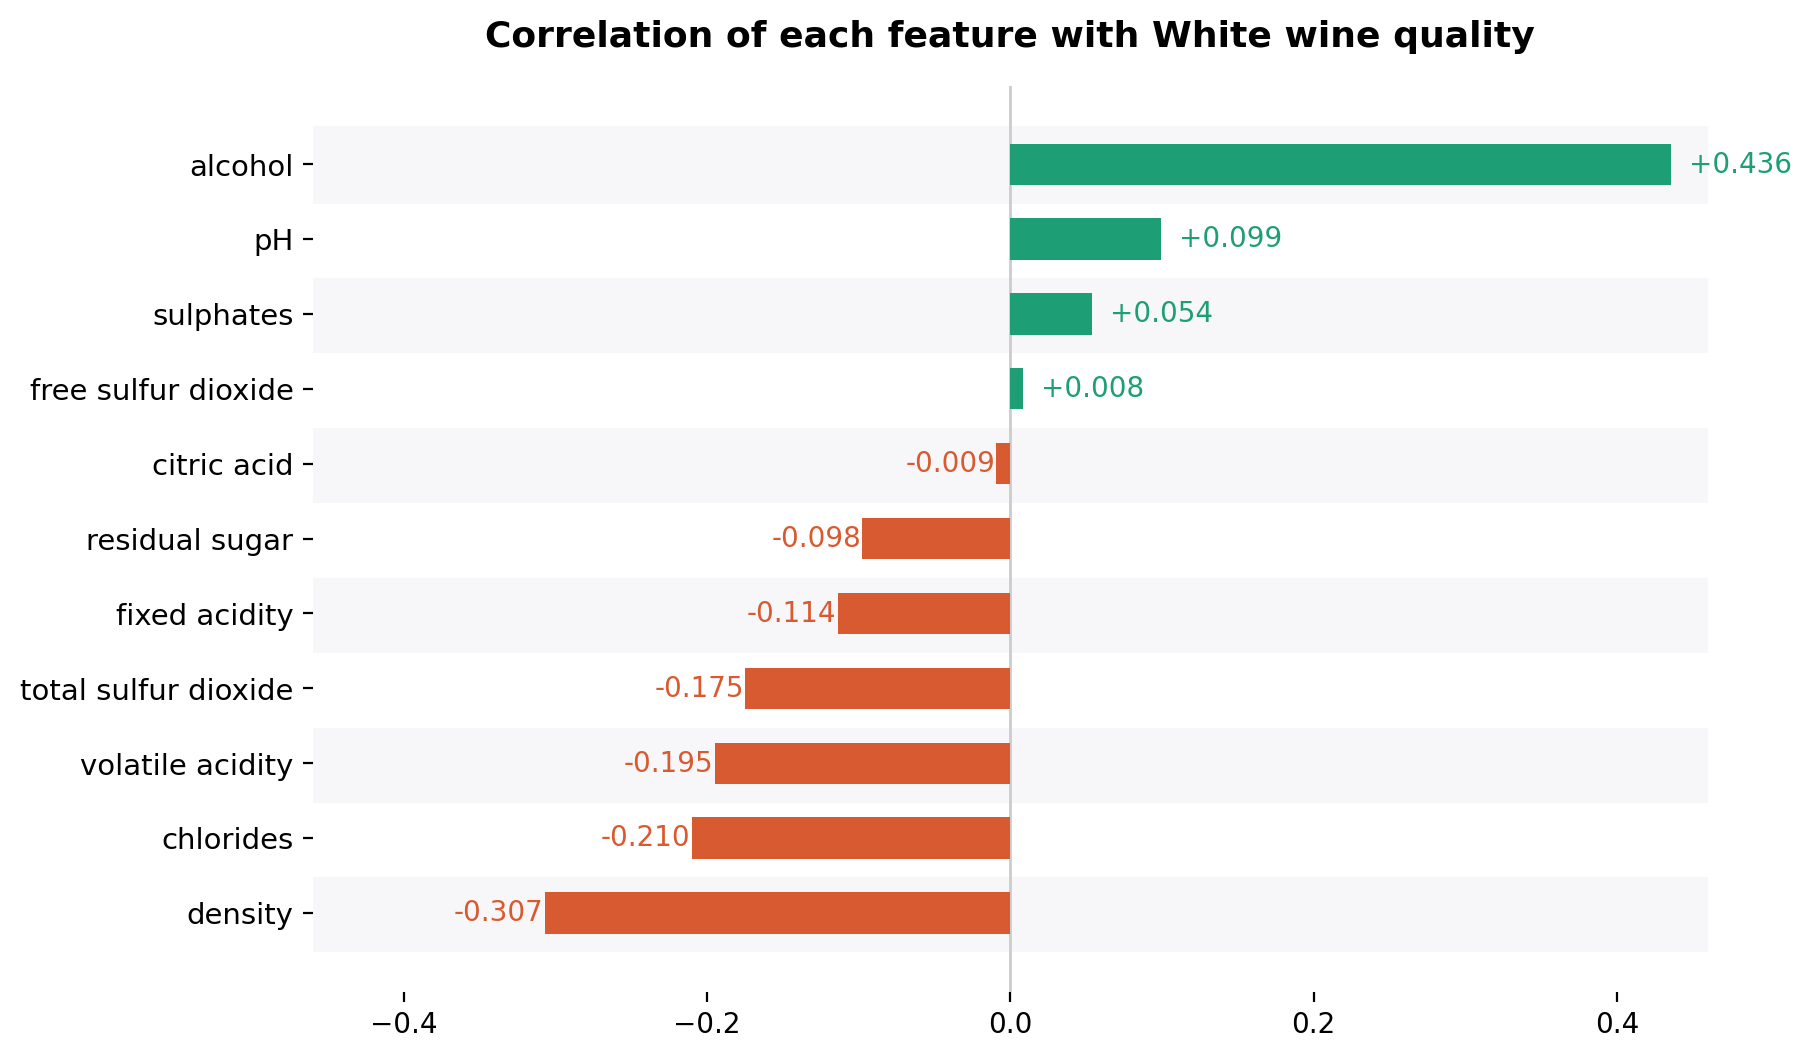

In [111]:
corr_white = wine_white.corr()['quality'].drop('quality').sort_values()

fig, ax1 = plt.subplots(figsize=(9,6), dpi=200)

for i in range(len(corr_white)):
    ax1.axhspan(i - 0.5, i + 0.5, color = '#f7f7f9' if i % 2 == 0 else 'white', zorder=0)
    
ax1.axvline(0, color='#cccccc', lw=1, zorder=1)

MAX_ABS = 0.46

for i, (feat, val) in enumerate(corr_white.items()):
    color= CORAL if val < 0 else TEAL
    ax1.barh(i, val, height=0.55, color=color, zorder=2)
    offset = -0.06 if val < 0 else 0.08
    sign = '' if val < 0 else '+'
    ha = 'left' if val < 0 else 'right'
    ax1.text(offset + val , i, f'{sign}{val:.3f}', ha=ha, va='center', color=color, zorder=3)

ax1.set_title('Correlation of each feature with White wine quality', fontsize=13, fontweight='bold', pad=14)
ax1.set_xlim(-MAX_ABS, MAX_ABS)
ax1.set_yticks(range(len(corr_white)))
ax1.set_yticklabels(corr_white.index, fontsize=10.5)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.xaxis.grid(False)

#plt.savefig('images/wine-white-correlation')

In [17]:
quality_order = sorted(wine_white['quality'].unique())

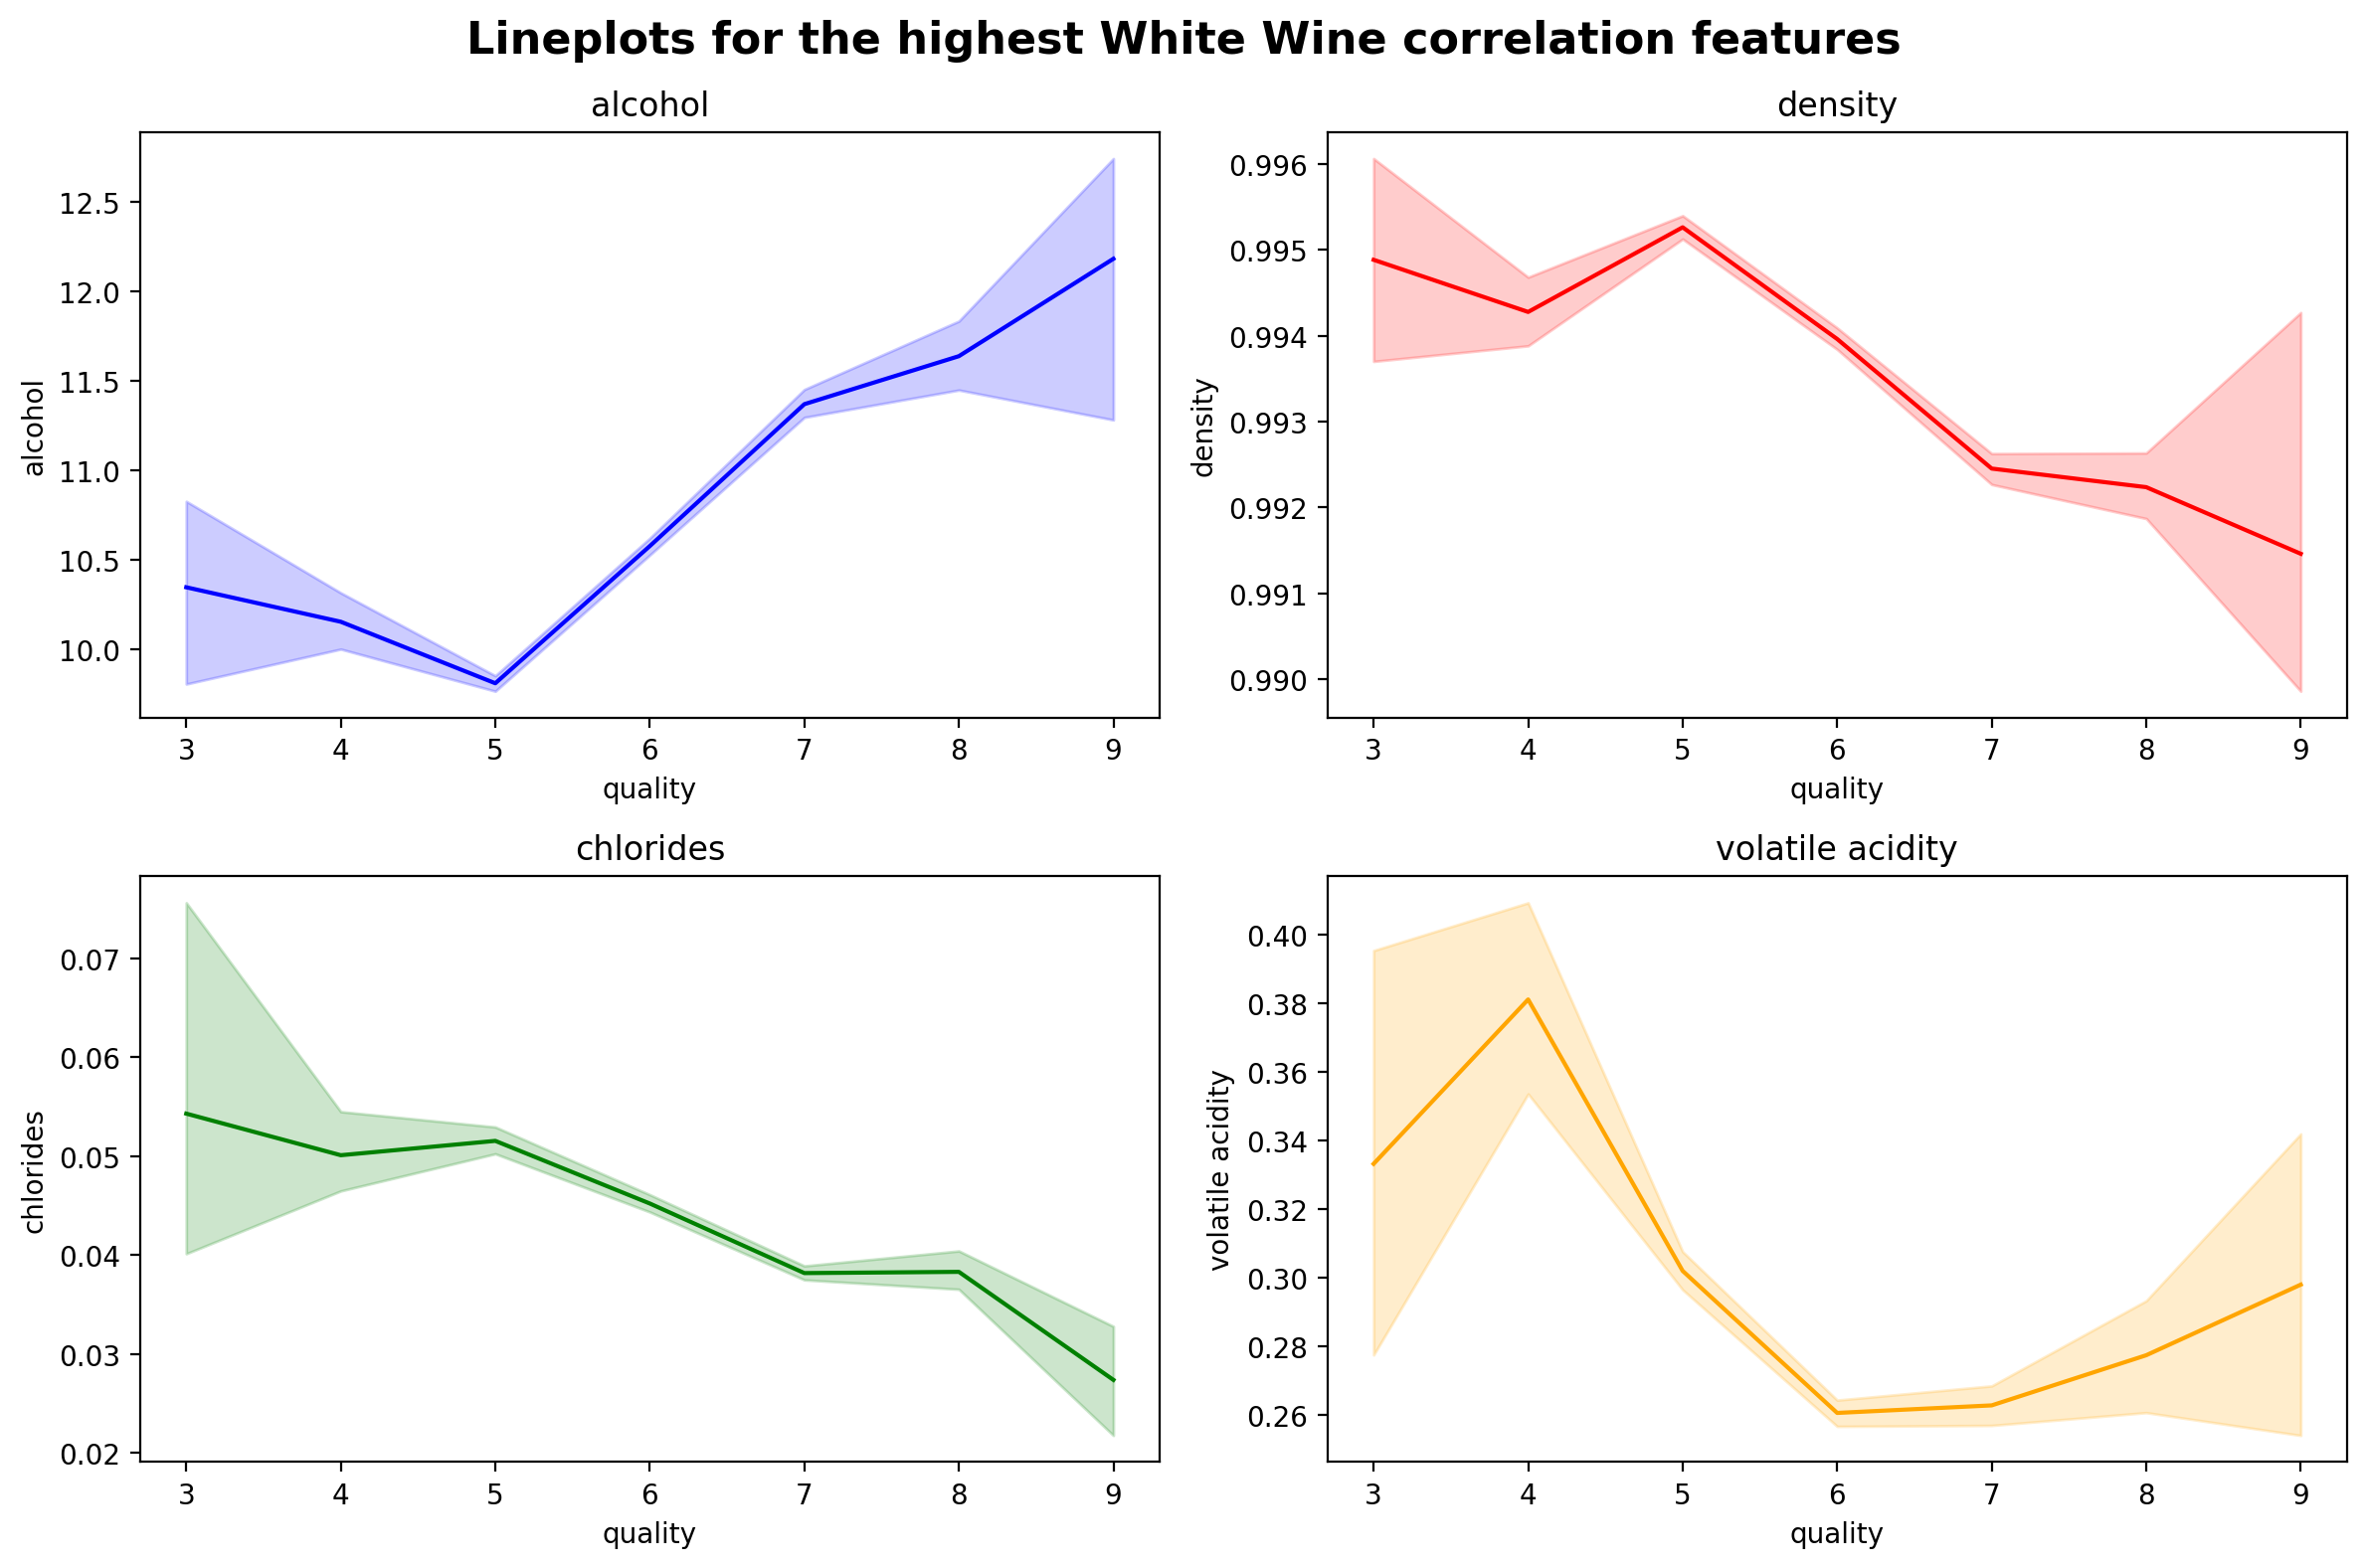

In [112]:
#wine_white_melted = wine_white.melt(id_vars='quality', 
#                                    value_vars=['alcohol', 'density', 'chlorides', 'volatile acidity'], 
#                                    var_name='variables', 
#                                    value_name='values')

#fig, ax = plt.subplots(figsize=(9,5), dpi=200)
#sns.lineplot(wine_white_melted, x='quality', y='values',hue='variables')
cols = ['alcohol', 'density', 'chlorides', 'volatile acidity']
colors = ['blue', 'red', 'green', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)
axes = axes.flatten()


for i, col in enumerate(cols):
    sns.lineplot(data=wine_white, x='quality', y=col, ax=axes[i], color=colors[i])
    axes[i].set_title(col)
plt.suptitle('Lineplots for the highest White Wine correlation features', fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('images/wine-white-lineplots')

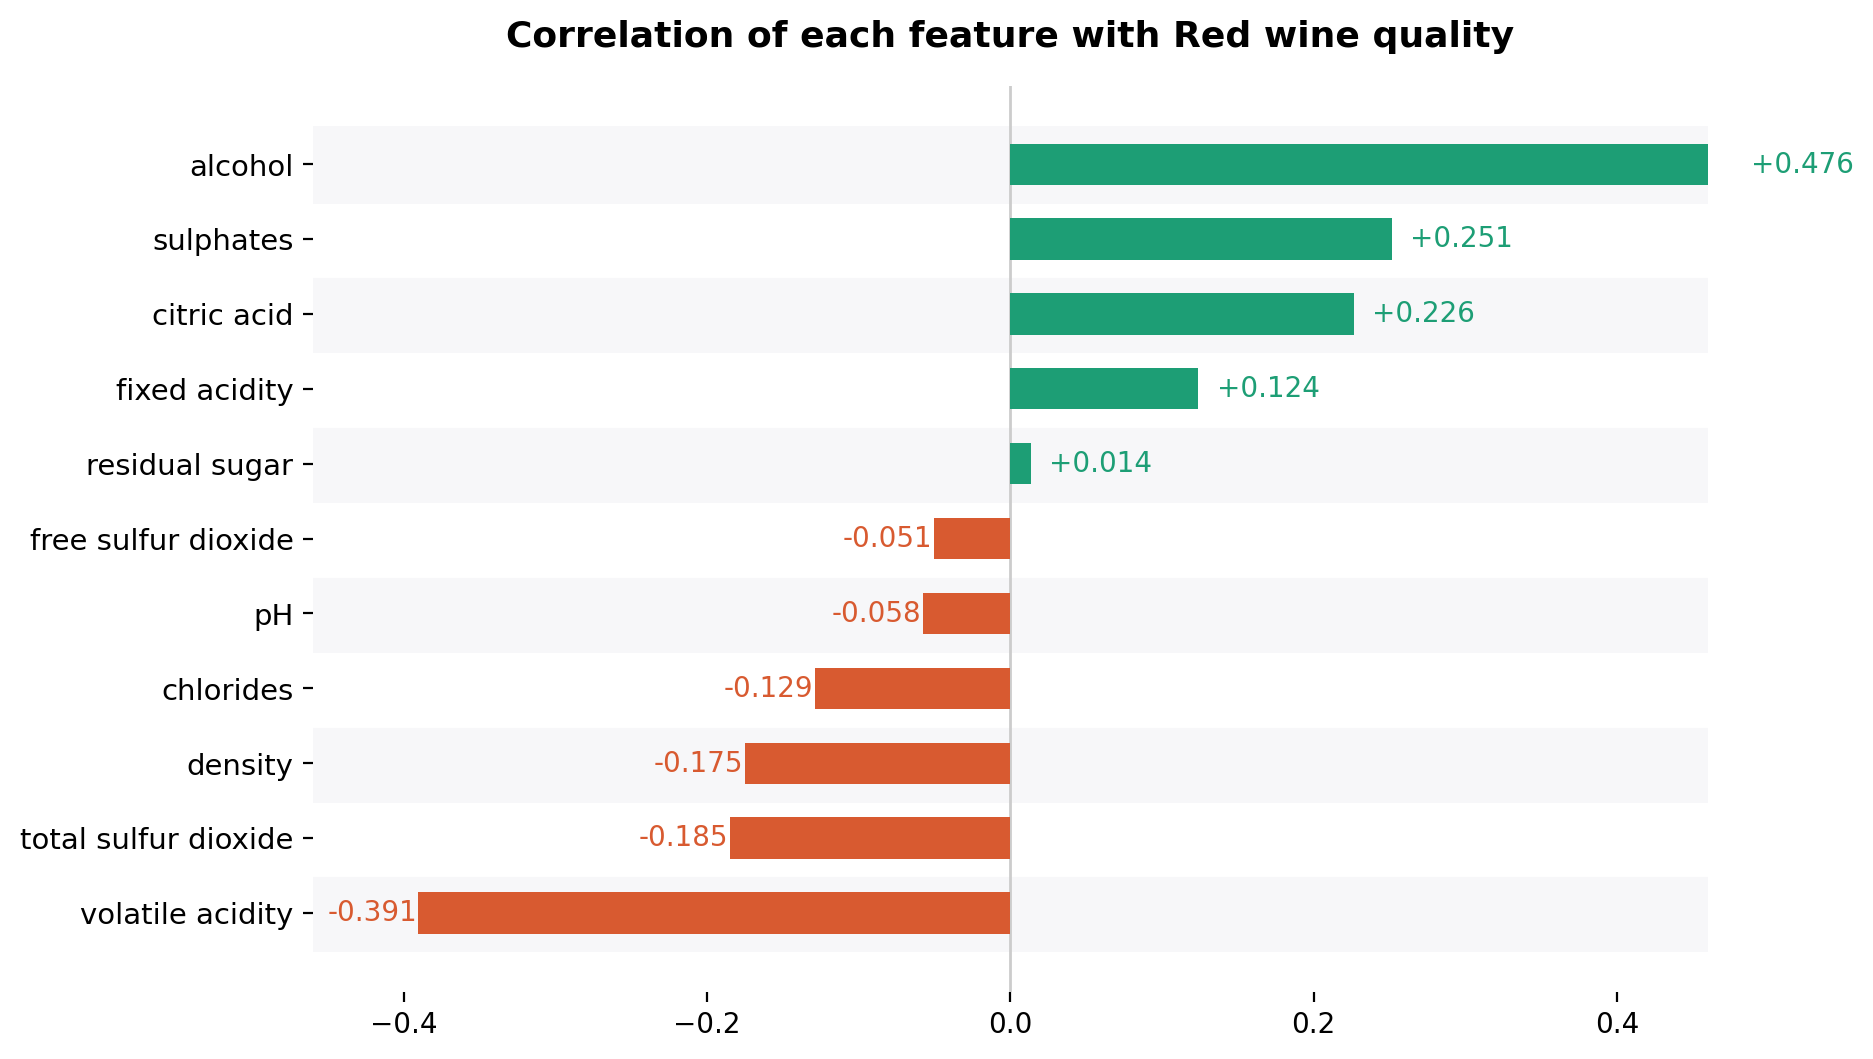

In [113]:
corr_red = wine_red.corr()['quality'].drop('quality').sort_values()

fig, ax1 = plt.subplots(figsize=(9,6), dpi=200)

for i in range(len(corr_red)):
    ax1.axhspan(i - 0.5, i + 0.5, color = '#f7f7f9' if i % 2 == 0 else 'white', zorder=0)
    
ax1.axvline(0, color='#cccccc', lw=1, zorder=1)

MAX_ABS = 0.46

for i, (feat, val) in enumerate(corr_red.items()):
    color= CORAL if val < 0 else TEAL
    ax1.barh(i, val, height=0.55, color=color, zorder=2)
    offset = -0.06 if val < 0 else 0.08
    sign = '' if val < 0 else '+'
    ha = 'left' if val < 0 else 'right'
    ax1.text(offset + val , i, f'{sign}{val:.3f}', ha=ha, va='center', color=color, zorder=3)

ax1.set_title('Correlation of each feature with Red wine quality', fontsize=13, fontweight='bold', pad=14)
ax1.set_xlim(-MAX_ABS, MAX_ABS)
ax1.set_yticks(range(len(corr_red)))
ax1.set_yticklabels(corr_red.index, fontsize=10.5)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.xaxis.grid(False)
plt.savefig('images/wine-red-correlation')

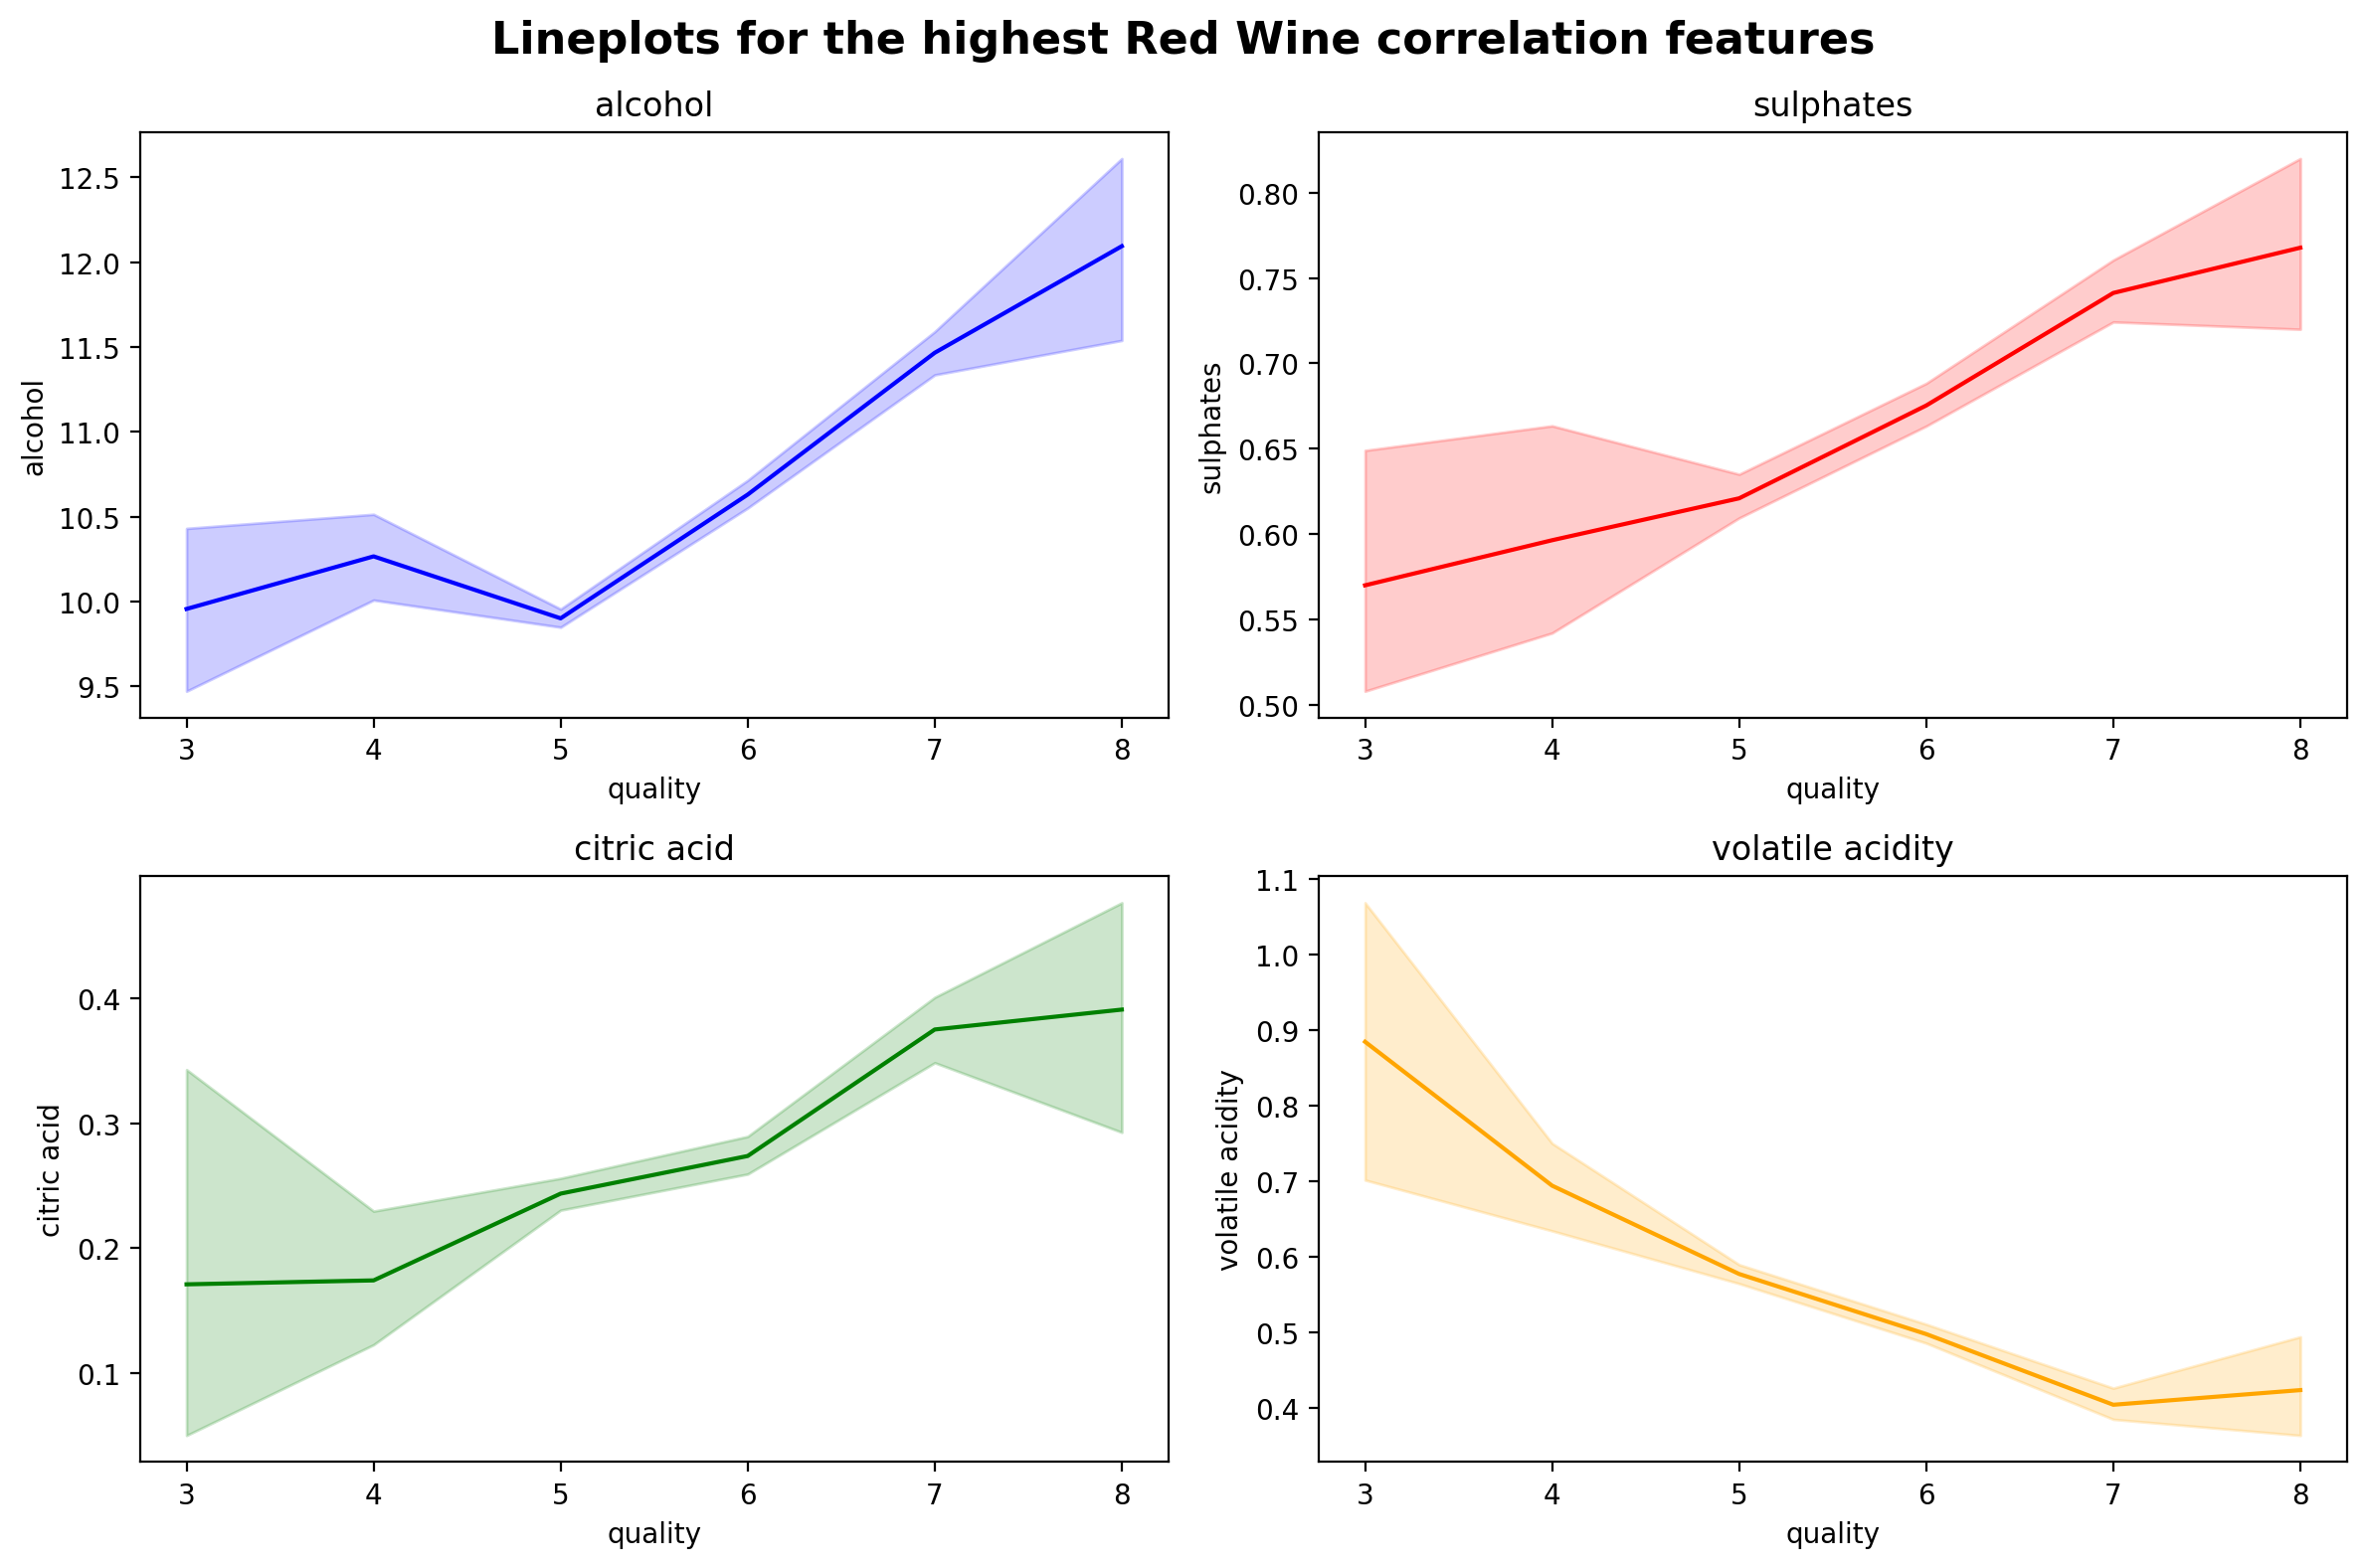

In [114]:
cols = ['alcohol', 'sulphates', 'citric acid', 'volatile acidity']
colors = ['blue', 'red', 'green', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)
axes = axes.flatten()


for i, col in enumerate(cols):
    sns.lineplot(data=wine_red, x='quality', y=col, ax=axes[i], color=colors[i])
    axes[i].set_title(col)

plt.suptitle('Lineplots for the highest Red Wine correlation features', fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('images/wine-red-lineplots')

In [83]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

y_white = wine_white['quality']
X_white = wine_white.drop('quality', axis=1)

In [88]:
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(X_white, y_white, test_size=0.15, random_state=101)

In [23]:
n_estimators=[64,100,128,200]
max_features= [2,3,4]
bootstrap = [True,False]
oob_score = [True,False]

In [24]:
param_grid = {'n_estimators':n_estimators,
             'max_features':max_features,
             'bootstrap':bootstrap,
             'oob_score':oob_score}

In [25]:
rfc_white = RandomForestClassifier()
grid_white = GridSearchCV(rfc_white,param_grid)

In [26]:
grid_white.fit(X_white_train,y_white_train)

/home/michael/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/home/michael/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/michael/.local/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/michael/.local/lib/python3.10/site-packages/sklearn/ensemble/_forest.py", line 447, in fit
    raise ValueError("Out of bag estimatio

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [64, 100, ...], 'oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [27]:
grid_white.best_params_

{'bootstrap': True, 'max_features': 3, 'n_estimators': 100, 'oob_score': False}

In [93]:
feature_names_white = X_white_train.columns.tolist()
importances_white = grid_white.best_estimator_.feature_importances_
feature_imp_white = pd.DataFrame({'Feature': feature_names_white, 'Importance': importances_white}).sort_values(
    'Importance', ascending=False)
print(feature_imp_white)

                 Feature  Importance
10               alcohol    0.113333
7                density    0.109250
1       volatile acidity    0.099924
5    free sulfur dioxide    0.092869
6   total sulfur dioxide    0.089537
3         residual sugar    0.087804
8                     pH    0.085275
4              chlorides    0.084991
2            citric acid    0.082389
9              sulphates    0.080602
0          fixed acidity    0.074026


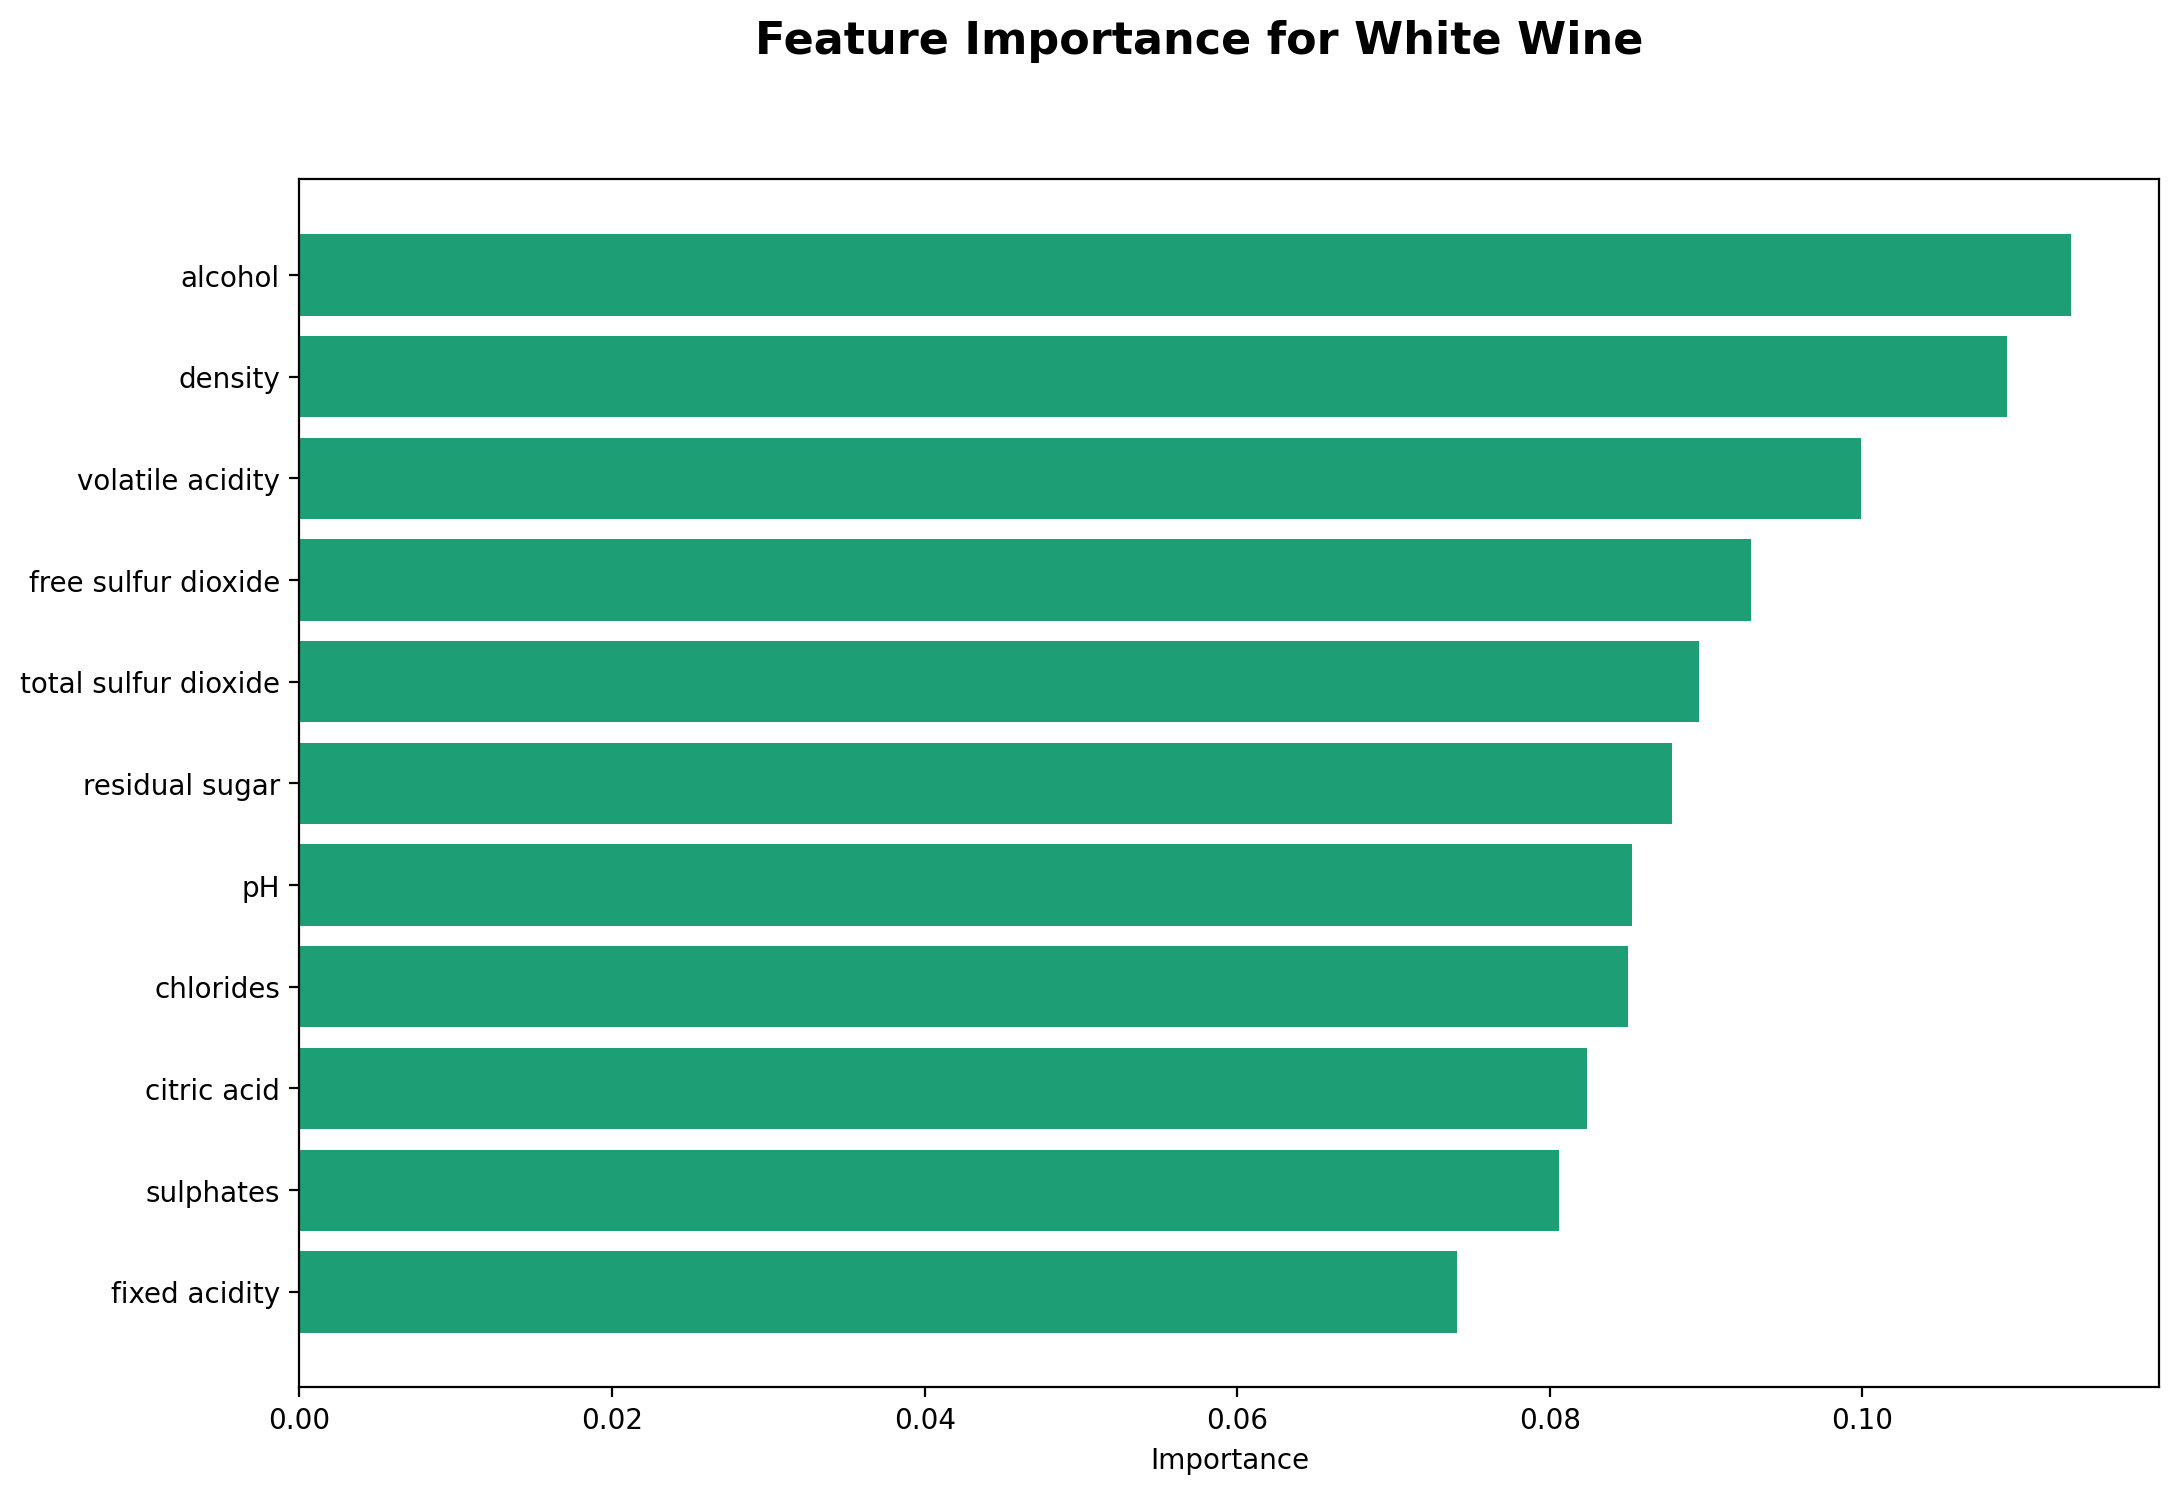

In [115]:
fig, axes = plt.subplots(figsize=(12, 8), dpi=200)
axes.barh(feature_imp_white['Feature'], feature_imp_white['Importance'], color=TEAL)
plt.xlabel('Importance')
plt.suptitle('Feature Importance for White Wine', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
#plt.savefig('images/feature-importance-white')

In [28]:
predictions_white = grid_white.predict(X_white_test)

In [29]:
print(classification_report(y_white_test,predictions_white))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       1.00      0.18      0.30        34
           5       0.72      0.69      0.70       240
           6       0.64      0.77      0.70       317
           7       0.64      0.59      0.61       112
           8       0.73      0.29      0.41        28

    accuracy                           0.67       735
   macro avg       0.62      0.42      0.45       735
weighted avg       0.68      0.67      0.65       735



/home/michael/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/michael/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/michael/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
confusion_matrix(y_white_test, predictions_white)

array([[  0,   0,   2,   2,   0,   0],
       [  0,   6,  18,   9,   1,   0],
       [  0,   0, 166,  73,   1,   0],
       [  0,   0,  43, 245,  26,   3],
       [  0,   0,   2,  44,  66,   0],
       [  0,   0,   0,  11,   9,   8]])

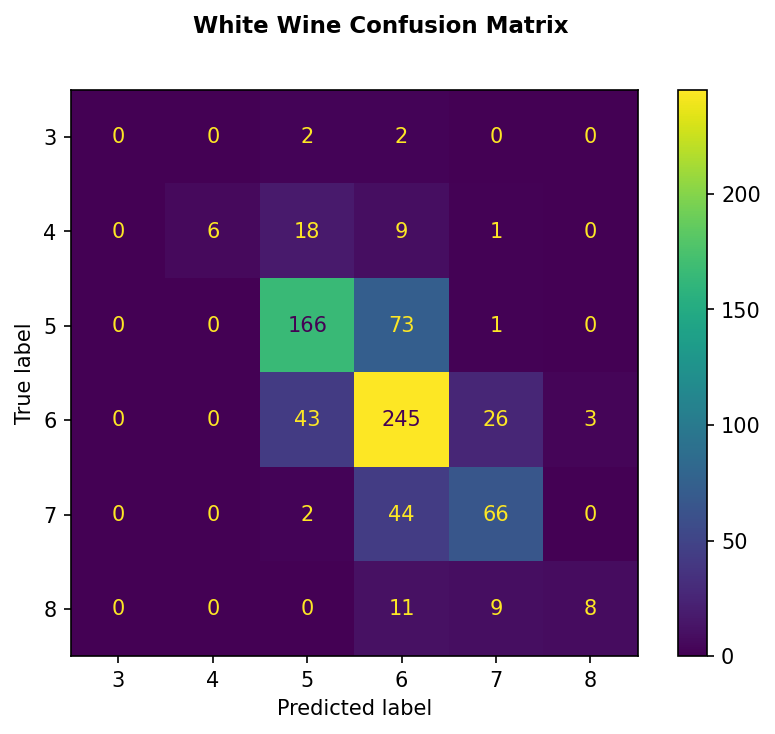

In [116]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ConfusionMatrixDisplay.from_estimator(grid_white, X_white_test, y_white_test, ax=ax)

plt.suptitle('White Wine Confusion Matrix', fontsize=11, fontweight='bold')
#plt.savefig('images/wine-white-confusion-matrix')

In [33]:
y_red = wine_red['quality']
X_red = wine_red.drop('quality', axis=1)

In [89]:
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(X_red, y_red, test_size=0.15, random_state=101)

In [35]:
rfc_red = RandomForestClassifier()
grid_red = GridSearchCV(rfc_red,param_grid)

In [36]:
grid_red.fit(X_red_train,y_red_train)

/home/michael/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/home/michael/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/michael/.local/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/michael/.local/lib/python3.10/site-packages/sklearn/ensemble/_forest.py", line 447, in fit
    raise ValueError("Out of bag estimatio

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [64, 100, ...], 'oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [37]:
grid_red.best_params_

{'bootstrap': True, 'max_features': 4, 'n_estimators': 100, 'oob_score': False}

In [94]:
feature_names_red = X_red_train.columns.tolist()
importances_red = grid_red.best_estimator_.feature_importances_
feature_imp_red = pd.DataFrame({'Feature': feature_names_red, 'Importance': importances_red}).sort_values(
    'Importance', ascending=False)
print(feature_imp_red)

                 Feature  Importance
10               alcohol    0.158296
9              sulphates    0.110953
1       volatile acidity    0.108707
6   total sulfur dioxide    0.107365
7                density    0.085413
4              chlorides    0.079492
0          fixed acidity    0.074623
8                     pH    0.074438
2            citric acid    0.072290
3         residual sugar    0.068770
5    free sulfur dioxide    0.059653


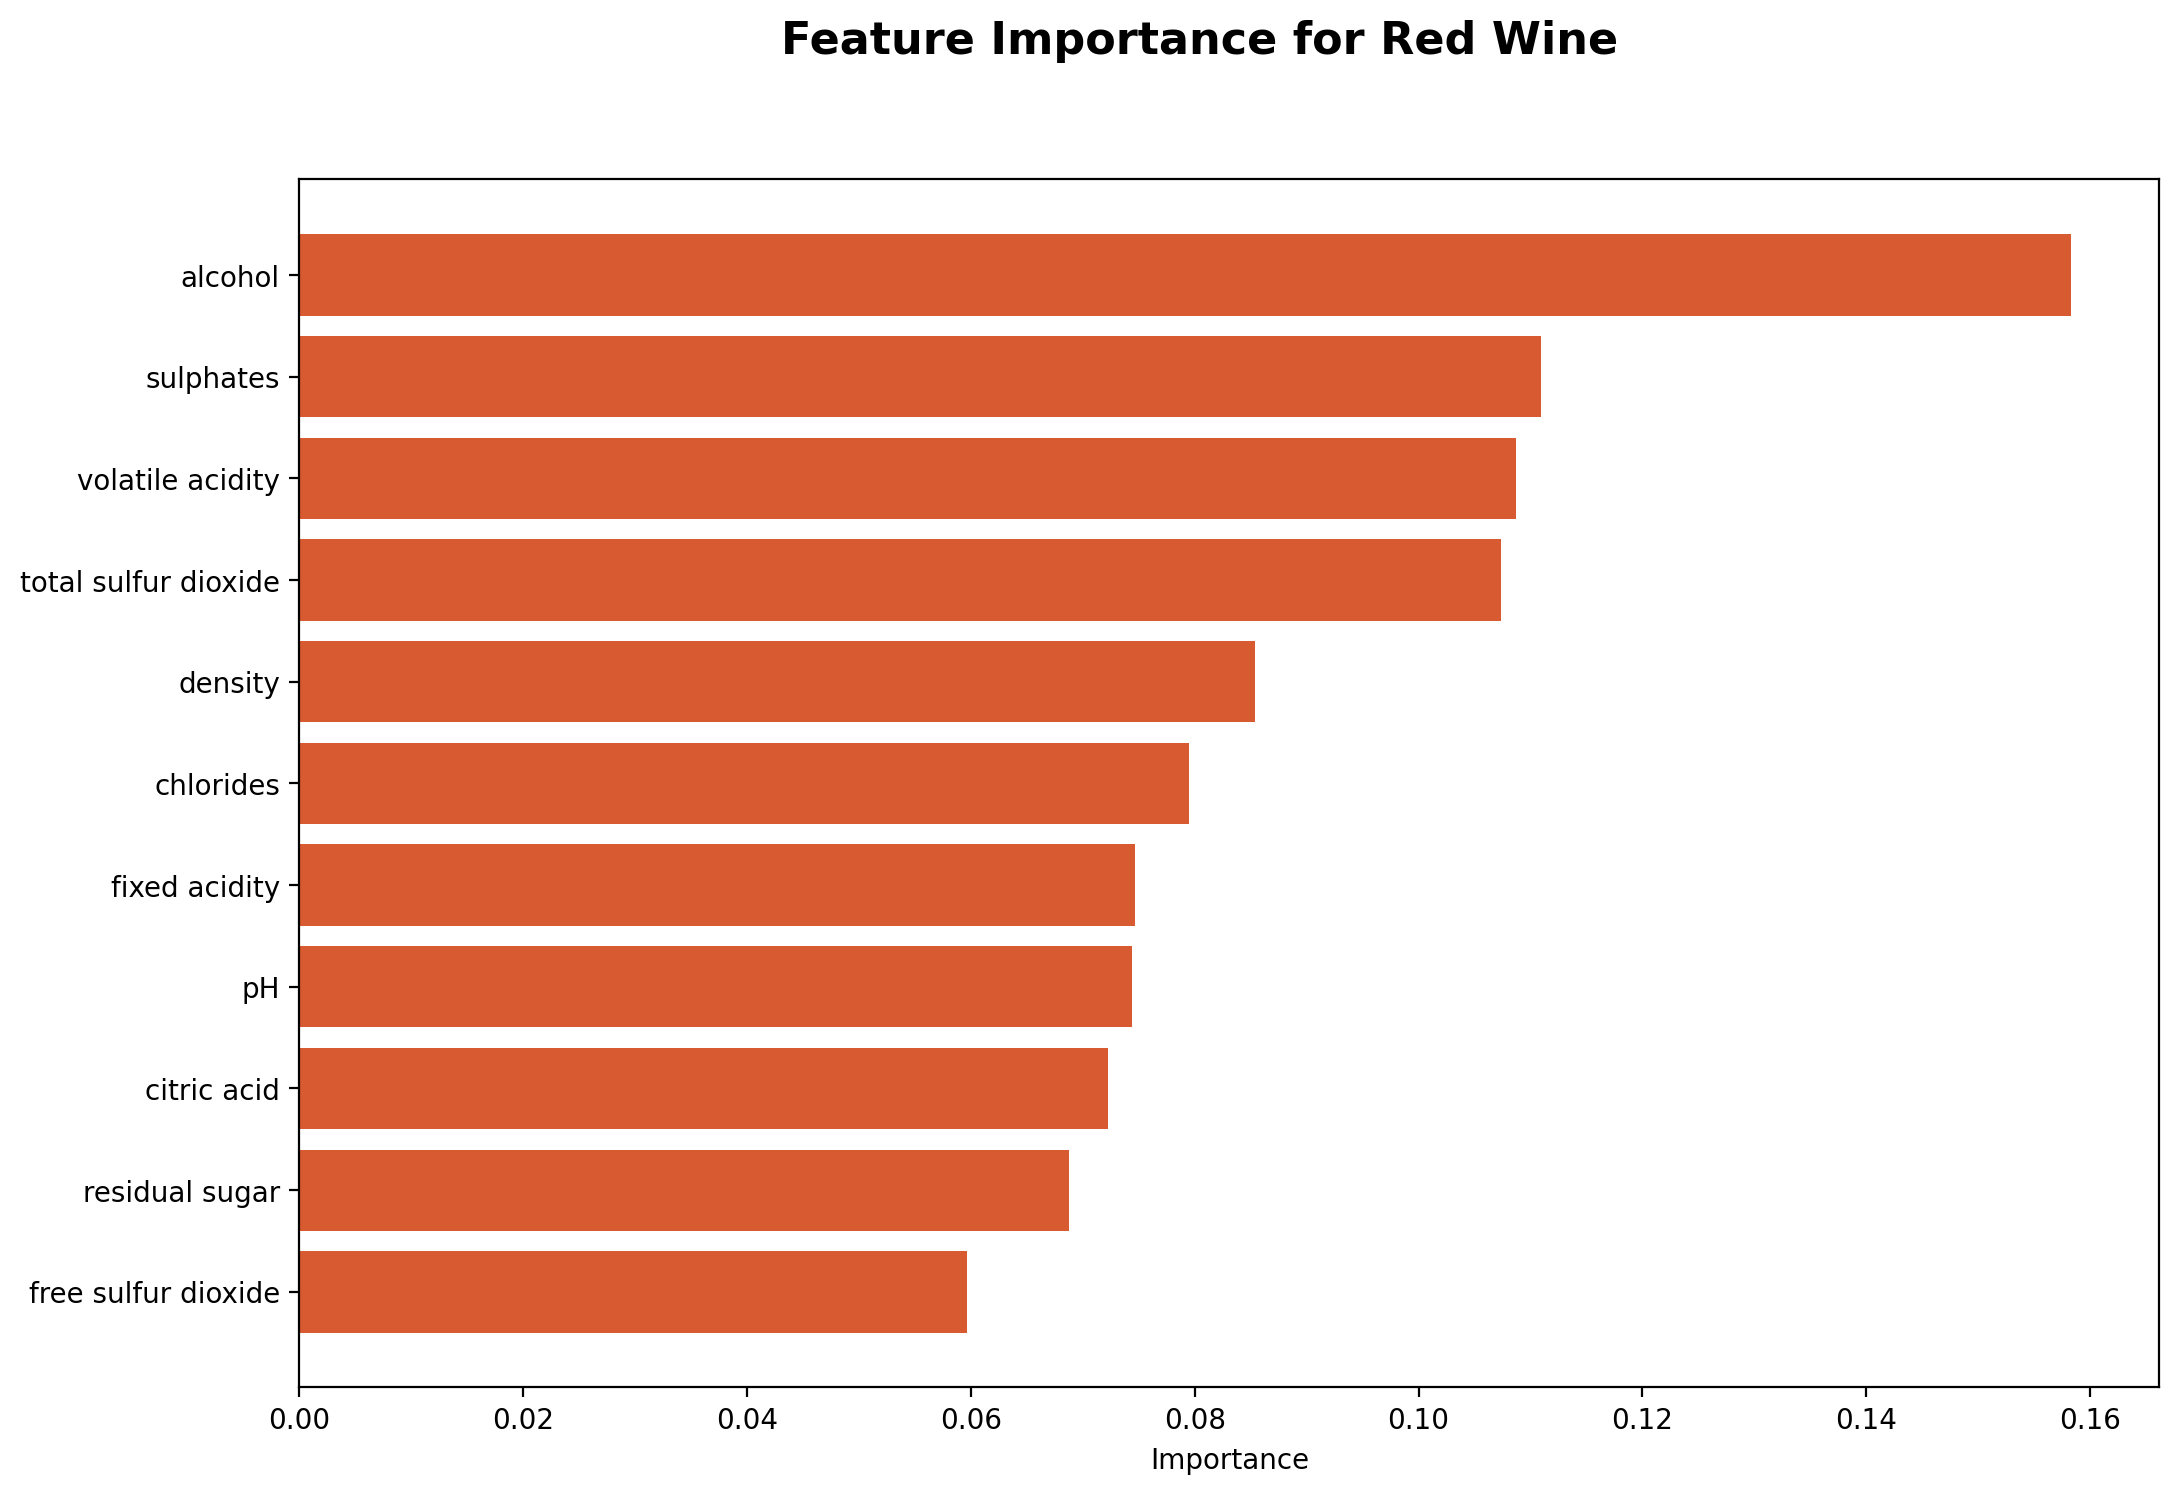

In [117]:
fig, axes = plt.subplots(figsize=(12, 8), dpi=200)
axes.barh(feature_imp_red['Feature'], feature_imp_red['Importance'], color=CORAL)
plt.xlabel('Importance')
plt.suptitle('Feature Importance for Red Wine', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
#plt.savefig('images/feature-importance-red')

In [38]:
predictions_red = grid_red.predict(X_red_test)

In [39]:
print(classification_report(y_red_test,predictions_red))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        11
           5       0.71      0.71      0.71       100
           6       0.60      0.77      0.68        92
           7       0.57      0.38      0.45        32
           8       0.00      0.00      0.00         2

    accuracy                           0.64       240
   macro avg       0.31      0.31      0.31       240
weighted avg       0.60      0.64      0.62       240



/home/michael/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/michael/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/michael/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


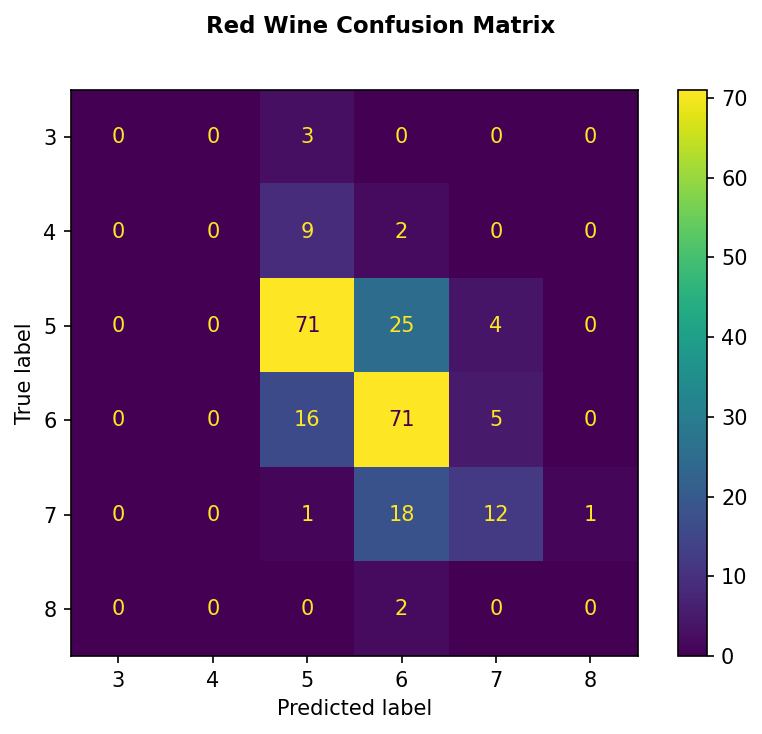

In [118]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ConfusionMatrixDisplay.from_estimator(grid_red, X_red_test, y_red_test, ax=ax)

plt.suptitle('Red Wine Confusion Matrix', fontsize=11, fontweight='bold')
#plt.savefig('images/wine-red-confusion-matrix')